In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from scipy.stats import linregress, uniform
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score, roc_auc_score, precision_score, precision_recall_curve, PrecisionRecallDisplay, confusion_matrix

In [2]:
warnings.filterwarnings('ignore')

# Load and inspect data

In [4]:
df = pd.read_csv('/content/Lead Scoring.csv.zip')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
df.shape

(9240, 37)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [8]:
binary_cats = ['Do Not Email','Do Not Call','Search','Magazine','Newspaper Article',
               'X Education Forums','Newspaper','Digital Advertisement','Through Recommendations',
               'Receive More Updates About Our Courses', 'Update me on Supply Chain Content','Get updates on DM Content',
               'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']

null_values = df[binary_cats].isnull().sum()
total = df[binary_cats].count()
yes_no = df[binary_cats].applymap(lambda x: 1 if x == 'Yes' or x == 'No' else 0).sum()
df_binary_cats = pd.DataFrame({'total': total,
                               'null_%': null_values/total*100,
                               'yes/no_%': yes_no/total*100})
df_binary_cats

,total,null_%,yes/no_%
Do Not Email,9240,0.0,100.0
Do Not Call,9240,0.0,100.0
Search,9240,0.0,100.0
Magazine,9240,0.0,100.0
Newspaper Article,9240,0.0,100.0
X Education Forums,9240,0.0,100.0
Newspaper,9240,0.0,100.0
Digital Advertisement,9240,0.0,100.0
Through Recommendations,9240,0.0,100.0
Receive More Updates About Our Courses,9240,0.0,100.0


# Seperate the train and test dataset

In [9]:
train, test = train_test_split(df, test_size=.2, random_state=12, stratify=df['Converted'])
print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

train shape: (7392, 37)
test shape: (1848, 37)


In [10]:
print(f'In the train set are {train.duplicated().sum()} duplicates')

In the train set are 0 duplicates


In [11]:
train['Asymmetrique Profile Index'].value_counts(dropna=False)

,count
Asymmetrique Profile Index,
NaN,3362
02.Medium,2243
01.High,1762
03.Low,25


In [12]:
train['Asymmetrique Activity Index'].value_counts(dropna=False)

,count
Asymmetrique Activity Index,
NaN,3362
02.Medium,3080
01.High,648
03.Low,302


# Data Cleaning and Feature Engineering

In [19]:
def data_cleaning(df):

  # drop columns id columns
  df = df.drop(['Prospect ID','Lead Number'], axis=1)

  # asymmetrique index columns transformation
  df['Asymmetrique Activity Index'] = df['Asymmetrique Activity Index'].str.split('.', expand=True)[0]\
                                                                        .str.replace('0','').str.replace('1','4')\
                                                                        .str.replace('3','1').str.replace('4','3')\
                                                                        .astype(np.float64
                                                                               )
  df['Asymmetrique Profile Index'] = df['Asymmetrique Profile Index'].str.split('.', expand=True)[0]\
                                                                        .str.replace('0','').str.replace('1','4')\
                                                                        .str.replace('3','1').str.replace('4','3')\
                                                                        .astype(np.float64
                                                                               )
  # binary encoding
  df[binary_cats] = df[binary_cats].applymap(lambda x: 0 if x == 'No' else 1)

  # rename columns for practicity
  df.columns = df.columns.str.replace(' ','_').str.lower()
  return df

# Convert custom function into transformer
initial_clean = FunctionTransformer(data_cleaning)

train_clean = initial_clean.fit_transform(train)

In [20]:
train_clean.lead_origin.value_counts(dropna=False)

,count
lead_origin,
Landing Page Submission,3906
API,2889
Lead Add Form,550
Lead Import,47


In [21]:
train_clean.lead_source.value_counts(dropna=False)

,count
lead_source,
Google,2326
Direct Traffic,2033
Olark Chat,1408
Organic Search,916
Reference,405
Welingak Website,111
Referral Sites,98
Facebook,46
NaN,27


In [22]:
train_clean.last_activity.value_counts(dropna=False)

,count
last_activity,
Email Opened,2712
SMS Sent,2224
Olark Chat Conversation,793
Page Visited on Website,506
Converted to Lead,336
Email Bounced,271
Email Link Clicked,211
Form Submitted on Website,97
NaN,80


In [23]:
train_clean.country.value_counts(dropna=False)

,count
country,
India,5201
NaN,1954
United States,57
United Arab Emirates,49
Singapore,21
Saudi Arabia,17
United Kingdom,13
Australia,9
Qatar,9


In [25]:
train_clean.specialization.value_counts(dropna=False)

,count
specialization,
Select,1554
NaN,1154
Finance Management,780
Marketing Management,682
Human Resource Management,661
Operations Management,407
Business Administration,329
IT Projects Management,295
Supply Chain Management,281


In [26]:
train_clean.how_did_you_hear_about_x_education.value_counts(dropna=False)

,count
how_did_you_hear_about_x_education,
Select,4023
NaN,1768
Online Search,647
Word Of Mouth,288
Student of SomeSchool,258
Other,139
Multiple Sources,128
Social Media,51
Advertisements,49


In [28]:
train_clean.what_is_your_current_occupation.value_counts(dropna=False)

,count
what_is_your_current_occupation,
Unemployed,4474
NaN,2159
Working Professional,559
Student,172
Other,14
Housewife,8
Businessman,6


In [29]:
train_clean.tags.value_counts(dropna=False)

,count
tags,
NaN,2687
Will revert after reading the email,1664
Ringing,958
Interested in other courses,418
Already a student,365
Closed by Horizzon,287
switched off,200
Busy,146
Lost to EINS,138


In [30]:
train_clean.lead_quality.value_counts(dropna=False)

,count
lead_quality,
NaN,3796
Might be,1249
Not Sure,884
High in Relevance,508
Worst,490
Low in Relevance,465


In [31]:
train_clean.lead_profile.value_counts(dropna=False)

,count
lead_profile,
Select,3283
NaN,2173
Potential Lead,1316
Other Leads,393
Student of SomeSchool,187
Lateral Student,22
Dual Specialization Student,18


In [32]:
train_clean.city.value_counts(dropna=False)

,count
city,
Mumbai,2581
Select,1806
NaN,1139
Thane & Outskirts,607
Other Cities,539
Other Cities of Maharashtra,349
Other Metro Cities,307
Tier II Cities,64


In [33]:
train_clean.last_notable_activity.value_counts(dropna=False)

,count
last_notable_activity,
Modified,2734
Email Opened,2219
SMS Sent,1759
Page Visited on Website,259
Olark Chat Conversation,153
Email Link Clicked,140
Email Bounced,49
Unsubscribed,39
Unreachable,24


In [34]:
def initial_feature_engineering(df):
  """Do some feature engineering"""
  # lead_source
  df['lead_source'] = df['lead_source'].str.replace('|'.join(['google','Pay per Click Ads']),'Google')
  df['lead_source'] = df['lead_source'].apply(lambda x: "Referral Sites" if 'blog' in str(x) else x)
  df['lead_source'] = df['lead_source'].str.replace('Live Chat','Olark Chat')
  df['lead_source'] = df['lead_source'].str.replace('bing','Organic Search')
  df['lead_source'] = df[df['lead_source'] != 'Other'].lead_source.apply(lambda x: "Other" if str(x) not in train_clean.lead_source.value_counts()[:8].index else x)

  # last_activity and last_notable_activity
  activity = ['last_activity','last_notable_activity']
  df[activity] = df[activity].apply(lambda x: x.str.replace('|'.join(['Email Received','SMS Sent']),'SMS/Email Sent'))
  df[activity] = df[activity].apply(lambda x: x.str.replace('|'.join(['Email Marked Spam','Email Bounced','Unsubscribed']),'Not interested in email'))
  df[activity] = df[activity].apply(lambda x: x.str.replace('Resubscribed to emails','Email Opened'))
  df[activity] = df[activity].apply(lambda x: x.str.replace('|'.join(['Visited Booth in Tradeshow','View in browser link Clicked']),'Page Visited on Website'))

  # country
  df['country'] = df['country'].apply(lambda x: np.nan if x in ['Unknown','unknown','Asia/Pacific Region'] else x)

  # specialization
  df['specialization'] = df['specialization'].str.replace('|'.join(['E-COMMERCE','E-Business']),'E-commerce')
  df['specialization'] = df['specialization'].str.replace('Banking, Investment And Insurance','Finance Management')
  df['specialization'] = df['specialization'].str.replace('Media and Advertising','Marketing Management')
  df['specialization'] = df['specialization'].str.replace('Select','Not Provided')

  # how_did_you_hear
  df['how_did_you_hear_about_x_education'] = df['how_did_you_hear_about_x_education'].str.replace('Select','Not Provided')
  df['how_did_you_hear_about_x_education'] = df['how_did_you_hear_about_x_education'].str.replace('|'.join(['SMS','Email']),'SMS/Email')

  # importance_in_course
  df['what_matters_most_to_you_in_choosing_a_course'] = df['what_matters_most_to_you_in_choosing_a_course'].str.replace('|'.join(['Flexibility & Convenience','Other']),"Better Career Prospects")

  # lead_profile
  df['lead_profile'] = df['lead_profile'].str.replace('Select','Not Assigned')

  # city
  df['city'] = df['city'].str.replace('Select','Not Provided')

  return df

initial_feature_engineering = FunctionTransformer(initial_feature_engineering)
train_clean = initial_feature_engineering.fit_transform(train_clean)

# Exlpore missing values

In [35]:
train_ = train_clean.copy()

# Set style for better visualizations
train_eda = train.copy()
sns.set_style('dark')
sns.set(rc={'axes.grid':False})
sns.set_palette('viridis')

In [36]:
null_ = pd.DataFrame()
null_['proportion'] = np.round(train_clean.isnull().sum()/len(train_clean),4) * 100
null_['amount'] = train_clean.isnull().sum()

# Show only those columns with at least 1 missing value
null_.sort_values(by='proportion', ascending=False)[null_.amount > 0]

,proportion,amount
lead_quality,51.35,3796
asymmetrique_activity_index,45.48,3362
asymmetrique_activity_score,45.48,3362
asymmetrique_profile_score,45.48,3362
asymmetrique_profile_index,45.48,3362
tags,36.35,2687
what_matters_most_to_you_in_choosing_a_course,29.40,2173
lead_profile,29.40,2173
what_is_your_current_occupation,29.21,2159
country,26.50,1959


In [37]:
def barplot_catcols(column,width,heigh):
  """Plot conversion rate"""
  fig, ax  = plt.subplots(figsize=(width,heigh))
  ax = sns.barplot(data=train_.fillna('NaN'), x='converted', y=column,
            order=order(train_.fillna('NaN'),column),
            orient='h', palette='viridis',
            seed=2)
  plt.title(f'Conversion Rate by {column.replace("_"," ").title()}', loc='left', size=18)
  return ax

def order(df,x,y=None):
    if y is not None:
        return df.groupby(x)[y].mean().sort_values(ascending=False).index
    else:
        return df.groupby(x)['converted'].mean().sort_values(ascending=False).index

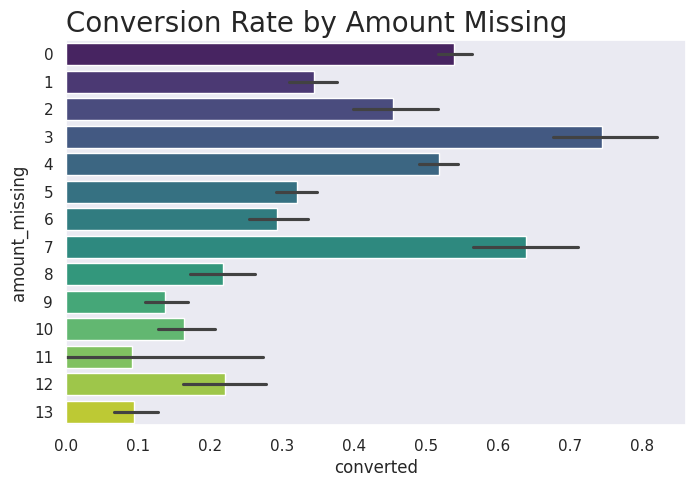

In [38]:
# Number of missing values in each row
train_['amount_missing'] = train_.isnull().sum(1)

# Plot the relation between amount missing and conversion rate
fig, ax  = plt.subplots(figsize=(8,5))
ax = sns.barplot(data=train_.fillna('NaN'), x='converted', y='amount_missing',
            orient='h', palette='viridis',
            seed=2)
plt.title(f'Conversion Rate by Amount Missing', loc='left', size=20)
plt.show()

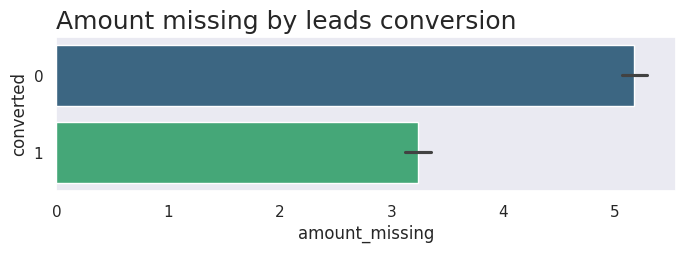

In [39]:
fig, ax  = plt.subplots(figsize=(8,2))
ax = sns.barplot(data=train_, x='amount_missing', y='converted',
            orient='h', palette=sns.color_palette('viridis',2),
            seed=2)
plt.title(f'Amount missing by leads conversion', loc='left', size=18)
plt.show()

# Correlation of numerical columns with converted columns

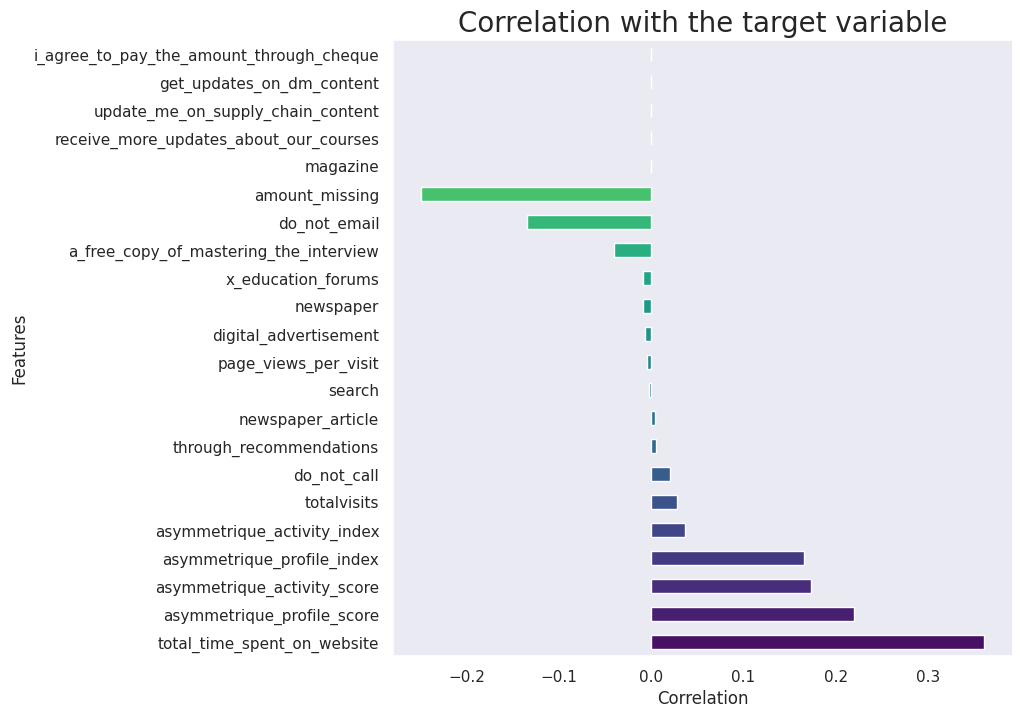

In [40]:
correlations = train_.select_dtypes('number').corr()['converted'].sort_values(ascending=False)

plt.figure(figsize=(8, 8))
correlations[1:].plot(kind='barh',
                 color=sns.color_palette('viridis', len(correlations)))

plt.title('Correlation with the target variable', fontsize=20)
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

In [41]:
print(f'Duplicate rows from original dataset: {train.duplicated().sum()}')
print(f'Duplicate rows after feature engineer: {train_clean.duplicated().sum()}')

Duplicate rows from original dataset: 0
Duplicate rows after feature engineer: 984


# Exploratory Data Analysis

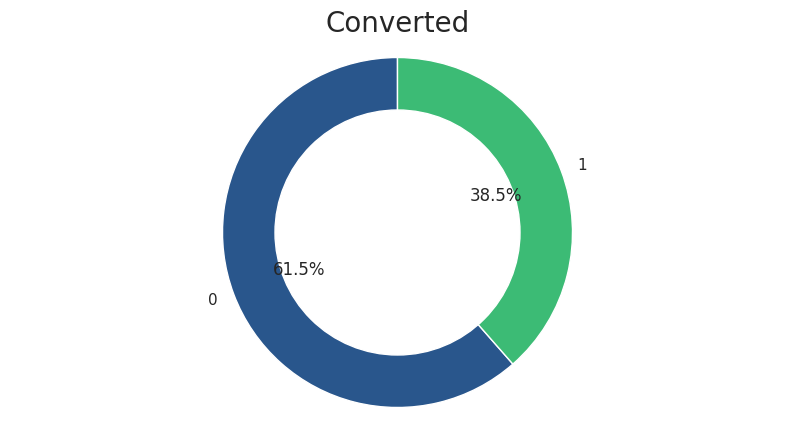

In [42]:
count = train_['converted'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.pie(count, labels=count.index, autopct='%1.1f%%', startangle=90, colors=['#29568CFF', '#3CBB75FF'])
ax.set_title('Converted', size=20)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

plt.axis('equal')
plt.show()

In [43]:
train_.loc[:,'asymmetrique_activity_index':'asymmetrique_profile_score'].corr().style.background_gradient(cmap='vlag_r')

,asymmetrique_activity_index,asymmetrique_profile_index,asymmetrique_activity_score,asymmetrique_profile_score
asymmetrique_activity_index,1.000000,-0.145399,0.855985,-0.122669
asymmetrique_profile_index,-0.145399,1.000000,-0.145366,0.883177
asymmetrique_activity_score,0.855985,-0.145366,1.000000,-0.114636
asymmetrique_profile_score,-0.122669,0.883177,-0.114636,1.000000


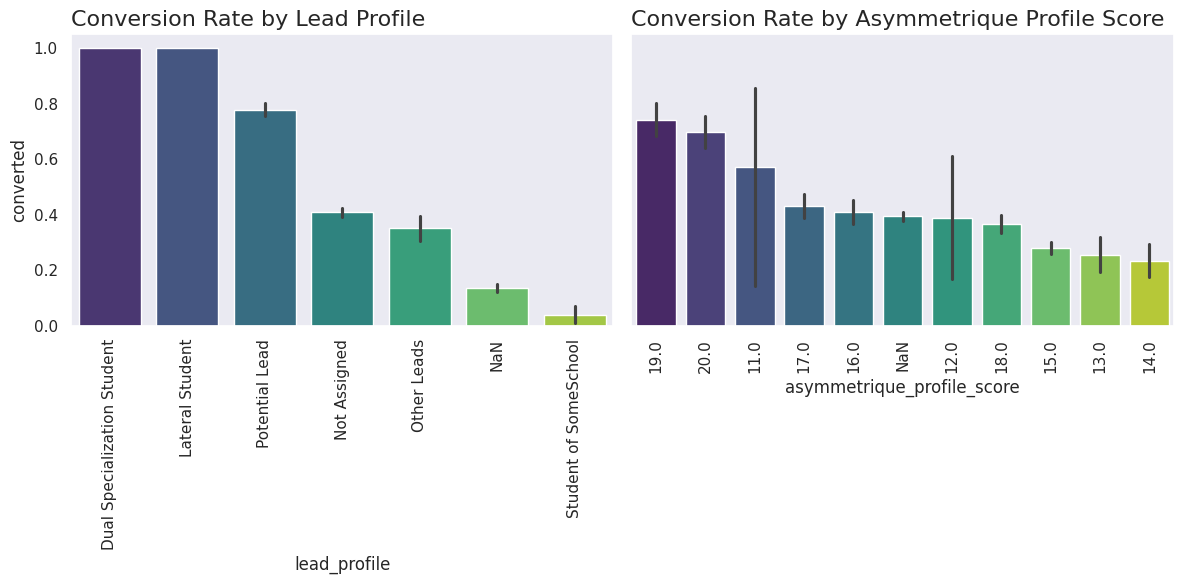

In [45]:
fig, ax  = plt.subplots(1,2, figsize=(12,6), sharey=True)

sns.barplot(data=train_.fillna('NaN'), x='lead_profile', y='converted',
            palette='viridis', order=order(train_.fillna('NaN'),'lead_profile'),
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Lead Profile', loc='left', size=16)

sns.barplot(data=train_.fillna('NaN'), x='asymmetrique_profile_score', y='converted',
                  palette='viridis', order=order(train_.fillna('NaN'),'asymmetrique_profile_score'),
                    seed=2, ax=ax[1])
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Asymmetrique Profile Score', loc='left', size=16)

plt.tight_layout()
plt.show()

In [46]:
activity_columns = ['totalvisits','total_time_spent_on_website','page_views_per_visit',
                    'asymmetrique_profile_score','asymmetrique_activity_score']

train_[activity_columns].corr().style.background_gradient(cmap='vlag_r')

,totalvisits,total_time_spent_on_website,page_views_per_visit,asymmetrique_profile_score,asymmetrique_activity_score
totalvisits,1.000000,0.261952,0.598883,0.129016,-0.061397
total_time_spent_on_website,0.261952,1.000000,0.323684,0.167992,-0.066008
page_views_per_visit,0.598883,0.323684,1.000000,0.165945,-0.171264
asymmetrique_profile_score,0.129016,0.167992,0.165945,1.000000,-0.114636
asymmetrique_activity_score,-0.061397,-0.066008,-0.171264,-0.114636,1.000000


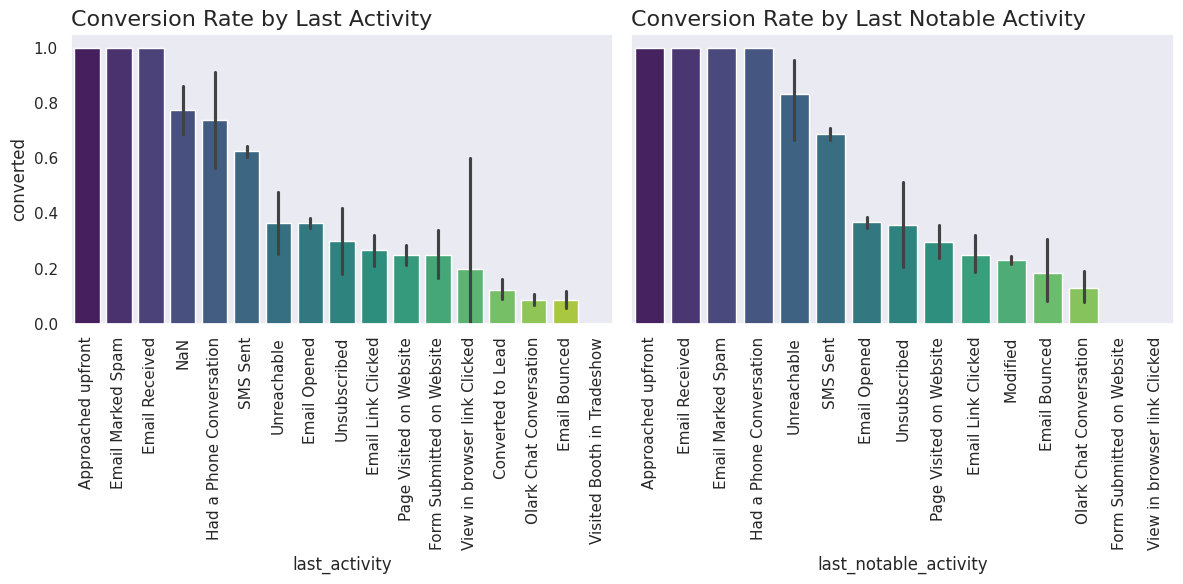

In [47]:
fig, ax  = plt.subplots(1,2, figsize=(12,6), sharey=True)

sns.barplot(data=train_.fillna('NaN'), x='last_activity', y='converted',
            order=order(train_.fillna('NaN'),'last_activity'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Last Activity', loc='left', size=16)

sns.barplot(data=train_.fillna('NaN'), x='last_notable_activity', y='converted',
                  order=order(train_.fillna('NaN'),'last_notable_activity'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Last Notable Activity', loc='left', size=16)

plt.tight_layout()
plt.show()

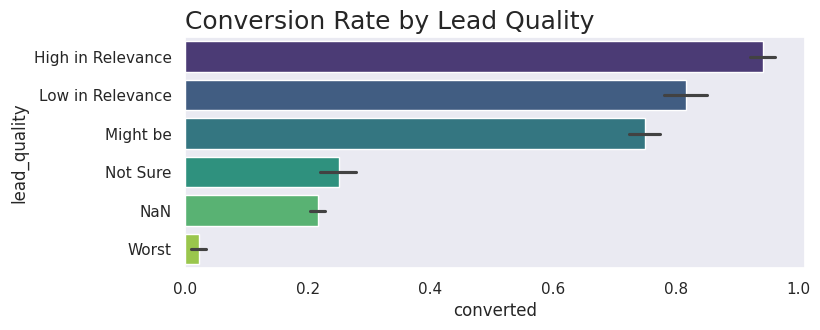

In [48]:
barplot_catcols('lead_quality',8,3)
plt.show()

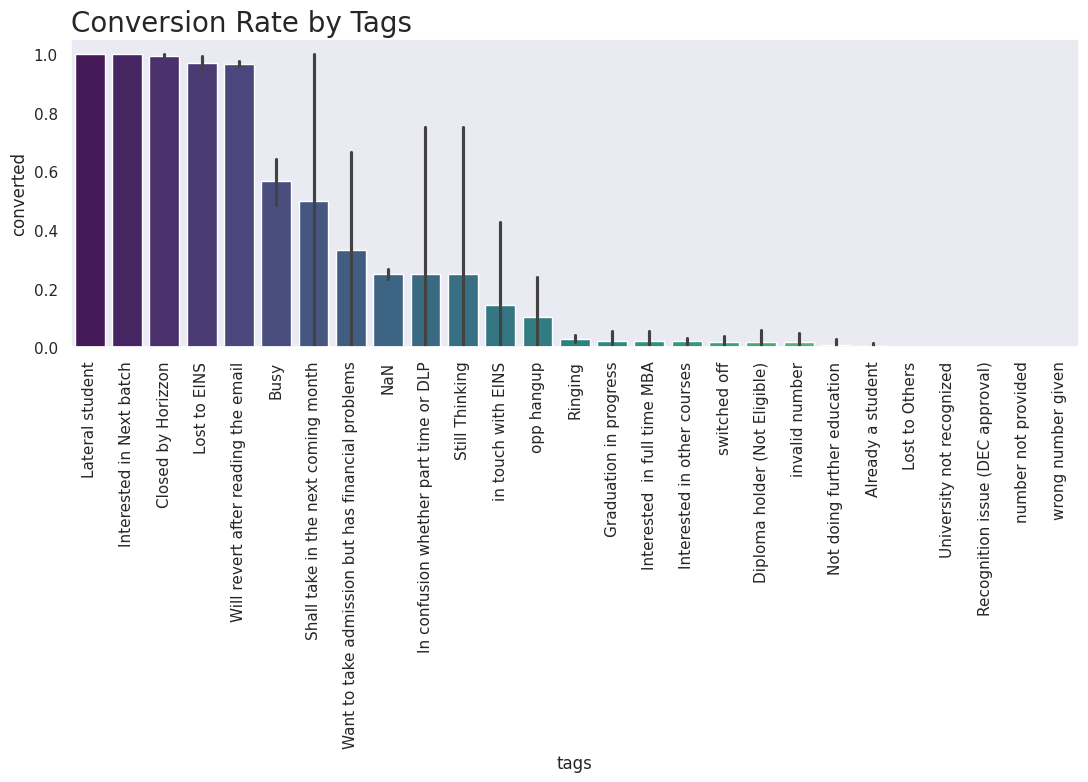

In [49]:
fig, ax  = plt.subplots(figsize=(13,4))

sns.barplot(data=train_.fillna('NaN'), x='tags', y='converted',
            order=order(train_.fillna('NaN'),'tags'),
            palette='viridis',
            seed=2)
plt.xticks(rotation=90)
plt.title(f'Conversion Rate by Tags', loc='left', size=20)
plt.show()

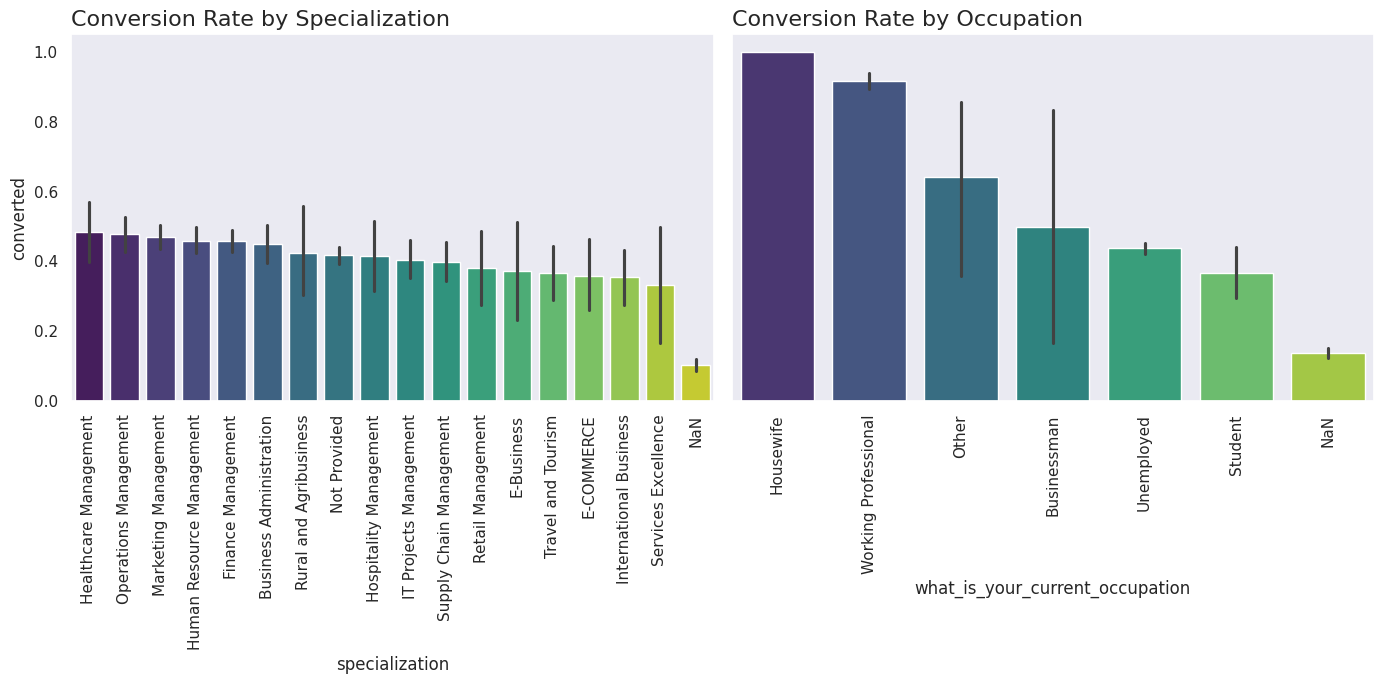

In [50]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=train_.fillna('NaN'), x='specialization', y='converted',
            order=order(train_.fillna('NaN'),'specialization'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Specialization', loc='left', size=16)

sns.barplot(data=train_.fillna('NaN'), x='what_is_your_current_occupation', y='converted',
                  order=order(train_.fillna('NaN'),'what_is_your_current_occupation'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Occupation', loc='left', size=16)

plt.tight_layout()
plt.show()


In [51]:
train_[['what_is_your_current_occupation','specialization']].isnull().sum(1).value_counts()

,count
0,5220
2,1141
1,1031


In [52]:
conversion_country = train_.groupby('country')['converted'].mean()
country_count = train_['country'].value_counts().sort_index()

fig = go.Figure(data=go.Choropleth(
    locations=conversion_country.index,
    locationmode='country names',
    z=conversion_country.values,
    text=country_count.values,
    colorscale='deep',
    colorbar_title='Conversion Rate',
    hovertemplate='%{location}<br>Conversion: %{z:.2f}<br>Count: %{text}',
))

fig.update_geos(projection_type="mercator")

fig.update_layout(
    title='Conversion Rate by Country',
    geo=dict(showcoastlines=True),
    font=dict(size=16),
)

fig.show()


In [53]:
train_['country'].value_counts().sort_index()

,count
country,
Australia,9
Bahrain,6
Bangladesh,2
Belgium,2
Canada,3
China,2
Denmark,1
France,4
Germany,4


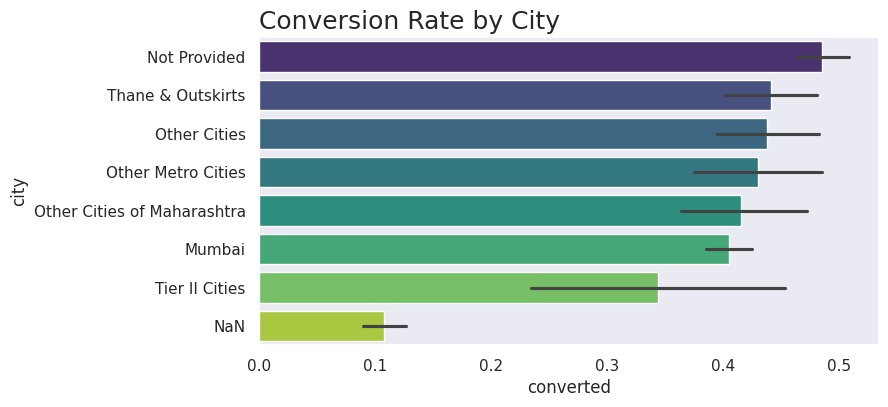

In [54]:
barplot_catcols('city',8,4)
plt.show()

In [55]:
print("Cities where country isn't India:")
train_[train_['country'] != 'India'].city.value_counts(dropna=False)

Cities where country isn't India:


,count
city,
Not Provided,992
NaN,693
Mumbai,244
Other Cities,98
Thane & Outskirts,83
Other Cities of Maharashtra,49
Other Metro Cities,27
Tier II Cities,5


In [56]:
print('Countries where City es equal to an Indian city:')
indian_cities = ['Mumbai','Thane & Outskirts','Other Cities of Maharashtra','Tier II Cities']
train_[train_.city.isin(indian_cities)].country.value_counts(dropna=False)

Countries where City es equal to an Indian city:


,count
country,
India,3220
NaN,270
United States,32
United Arab Emirates,19
Singapore,11
United Kingdom,9
Saudi Arabia,8
Australia,6
Qatar,5


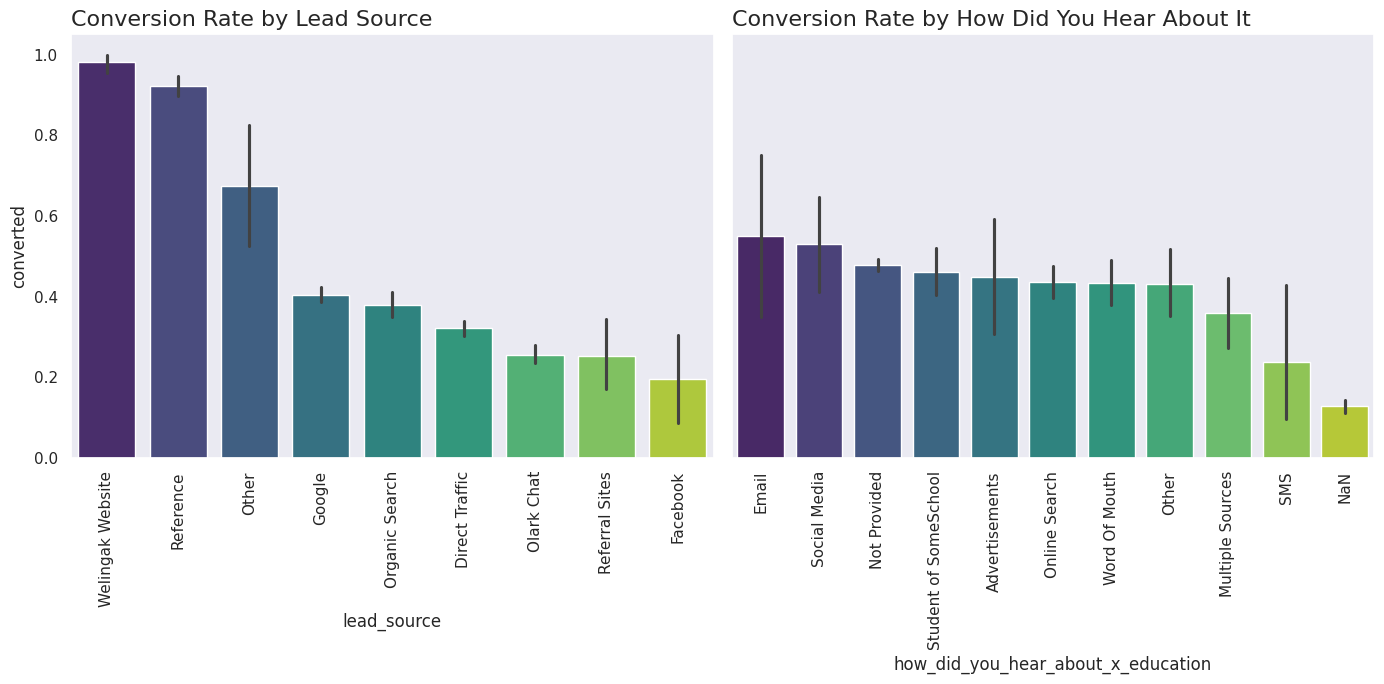

In [57]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=train_.fillna('NaN'), x='lead_source', y='converted',
            order=order(train_.fillna('NaN'),'lead_source'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Lead Source', loc='left', size=16)

sns.barplot(data=train_.fillna('NaN'), x='how_did_you_hear_about_x_education', y='converted',
                  order=order(train_.fillna('NaN'),'how_did_you_hear_about_x_education'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by How Did You Hear About It', loc='left', size=16)

plt.tight_layout()
plt.show()

In [58]:
train_.select_dtypes(include=['number']).nunique().sort_values()

,0
magazine,1
receive_more_updates_about_our_courses,1
get_updates_on_dm_content,1
update_me_on_supply_chain_content,1
i_agree_to_pay_the_amount_through_cheque,1
search,2
converted,2
do_not_email,2
digital_advertisement,2
newspaper,2


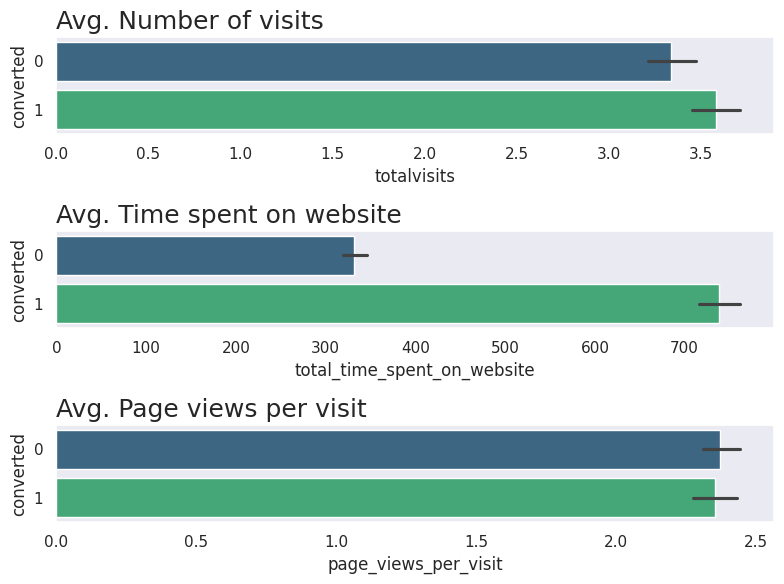

In [59]:
fig, ax  = plt.subplots(3, figsize=(8,6))
sns.barplot(data=train_, x='totalvisits', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_title(f'Avg. Number of visits', loc='left', size=18)

sns.barplot(data=train_, x='total_time_spent_on_website', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[1])
ax[1].set_title(f'Avg. Time spent on website', loc='left', size=18)

sns.barplot(data=train_, x='page_views_per_visit', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[2])
ax[2].set_title(f'Avg. Page views per visit', loc='left', size=18)

plt.tight_layout()
plt.show()

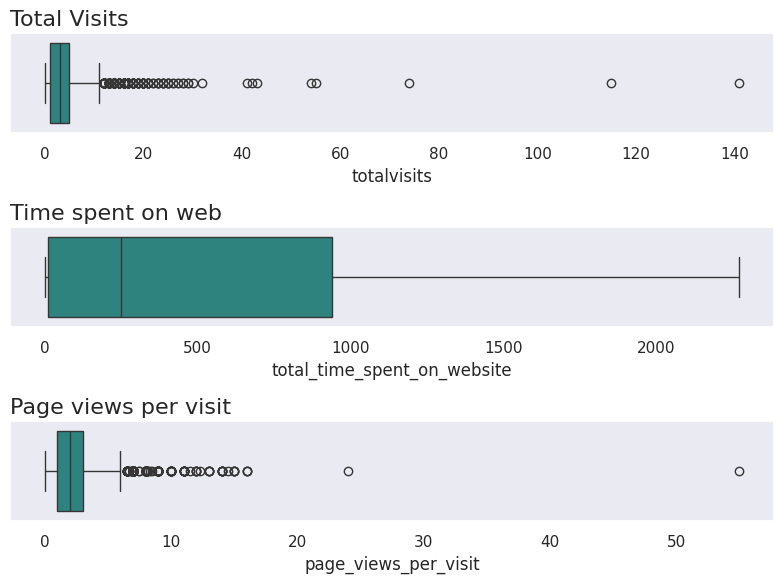

In [60]:
fig, ax = plt.subplots(3,1, figsize=(8,6))
sns.boxplot(data=train_, x='totalvisits',
              ax=ax[0], palette='viridis')
ax[0].set_title('Total Visits', loc='left', size=16)

sns.boxplot(data=train_, x='total_time_spent_on_website',
              ax=ax[1], palette='viridis')
ax[1].set_title('Time spent on web', loc='left', size=16)

sns.boxplot(data=train_, x='page_views_per_visit',
              ax=ax[2], palette='viridis')
ax[2].set_title('Page views per visit', loc='left', size=16)

plt.tight_layout()
plt.show()

In [61]:
def eda_feature_engineering(df):
  # tags column
  df['tags'] = df['tags'].str.replace('|'.join(['invalid number','wrong number given','number not provided']),'Not interest in calls')
  df['tags'] = df['tags'].str.replace('|'.join(["In confusion whether part time or DLP", "Interested in Next batch", "Shall take in the next coming month", "Still Thinking"]), "Shows certain interest")
  df['tags'] = df['tags'].str.replace("University not recognized","Not elegible")
  df['tags'] = df[df['tags'].notnull()].tags.apply(lambda x: 'Not elegible' if 'holder' in x else x)
  df['tags'] = df['tags'].str.replace('|'.join(["Interested in other courses", "Interested  in full time MBA", "Not doing further education"]),"Doesn't show interest")
  df['tags'] = df['tags'].str.replace('|'.join(["Ringing","switched off"]),"Still no contact")
  df['tags'] = df['tags'].str.replace('|'.join(["Want to take admission but has financial problems", "Graduation in progress"]),"Not elegible for the moment")
  df['tags'] = df[df['tags'].notnull()].tags.apply(lambda x: 'Not elegible for the moment' if 'Recognition' in x else x)
  df['tags'] = df[df['tags'].notnull()].tags.apply(lambda x: 'Other' if x not in df.tags.value_counts(dropna=False)[:12] else x)

  # country and city
  indian_cities = ['Mumbai','Thane & Outskirts','Other Cities of Maharashtra','Tier II Cities']
  df.loc[(df.country != 'India') & (df.city.isin(indian_cities)),'country'] = 'India'
  df['country'] = df.loc[df['country'].notnull(),'country'].apply(lambda x: 'Other' if x not in df.loc[df['country'] != 'Other','country'].value_counts()[:4] else x)

  # lead quality
  df['lead_quality'] = df['lead_quality'].fillna('Not Sure')

  # convert asymmetrique index columns in strings columns
  df[['asymmetrique_profile_index','asymmetrique_activity_index']] = df[['asymmetrique_profile_index','asymmetrique_activity_index']].astype(str)

  # drop columns with unique values
  drop_cols = ['magazine','receive_more_updates_about_our_courses','update_me_on_supply_chain_content',
               'get_updates_on_dm_content','i_agree_to_pay_the_amount_through_cheque']
  df = df.drop(drop_cols, axis=1)

  #add amount_missing column
  df['amount_missing'] = df.isnull().sum(1)
  return df

eda_feature_engineering = FunctionTransformer(eda_feature_engineering)

In [62]:
def cap_outliers(df):
  """Replace outliers with the 95th percentile"""
  num_cols = ['totalvisits','page_views_per_visit','total_time_spent_on_website']
  df[num_cols[0]].apply(lambda x: df[num_cols[0]].quantile(.95) if x > df[num_cols[0]].quantile(.95) else x)
  df[num_cols[1]].apply(lambda x: df[num_cols[1]].quantile(.95) if x > df[num_cols[1]].quantile(.95) else x)
  df[num_cols[2]].apply(lambda x: df[num_cols[2]].quantile(.95) if x > df[num_cols[2]].quantile(.95) else x)
  return df

cap_outliers = FunctionTransformer(cap_outliers)

In [63]:
cat_columns = ['lead_origin','lead_source','country','what_is_your_current_occupation',
                'what_matters_most_to_you_in_choosing_a_course','tags','lead_quality',
                'city','last_notable_activity']

num_cols = ['totalvisits','page_views_per_visit','total_time_spent_on_website',
            'asymmetrique_activity_score','asymmetrique_profile_score','amount_missing']

impute_knn = KNNImputer(n_neighbors=5)
impute_cons = SimpleImputer(strategy='constant', fill_value='Missing')
ohe = OneHotEncoder(handle_unknown='ignore')
sc = StandardScaler()

# Make pipelines for both type of columns treatments
pipe_cat = make_pipeline(impute_cons,ohe)
pipe_num = make_pipeline(sc,impute_knn)

impute_scale = make_column_transformer(
                                        (pipe_cat, cat_columns),
                                        (pipe_num,num_cols),
                                        remainder='drop'
                                            )

In [64]:
X_train = train.drop('Converted',axis=1)
y_train = train.loc[:,'Converted']

# Pipeline for all preprocessing steps

In [65]:
pipe = make_pipeline(
                    initial_clean,
                    initial_feature_engineering,
                    eda_feature_engineering,
                    cap_outliers,
                    impute_scale
              )
# Let's see how it looks
pipe

Pipeline(steps=[('functiontransformer-1',
                 FunctionTransformer(func=<function data_cleaning at 0x783d28fe96c0>)),
                ('functiontransformer-2',
                 FunctionTransformer(func=<function initial_feature_engineering at 0x783d290af7e0>)),
                ('functiontransformer-3',
                 FunctionTransformer(func=<function eda_feature_engineering at 0x783d1f5520c0>)),
                ('functiontransformer-4',
                 FunctionT...
                                                   'what_is_your_current_occupation',
                                                   'what_matters_most_to_you_in_choosing_a_course',
                                                   'tags', 'lead_quality',
                                                   'city',
                                                   'last_notable_activity']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler()),
                                                                  ('knnimputer',
                                                                   KNNImputer())]),
                                                  ['totalvisits',
                                                   'page_views_per_visit',
                                                   'total_time_spent_on_website',
                                                   'asymmetrique_activity_score',
                                                   'asymmetrique_profile_score',
                                                   'amount_missing'])]))])

In [66]:
X_train_pp = pipe.fit_transform(X_train)

# Modelling

In [68]:
# Use stratified fold for ensure that we shuffle the dataset and conserve classes
skfold = StratifiedKFold(5, shuffle=True, random_state=12)

def display_scores(model,scores,pred):
  print(f'----------- {model} -----------')
  print('')
  print("------------------ Cross validation scores:")
  print("Scores:", scores)
  print("Mean:", scores.mean())
  print("Standard deviation:", scores.std())
  print('')
  print("--------------- Scores in the training set:")
  print("Precision:", precision_score(y_train,pred))
  print("Recall:", recall_score(y_train,pred))
  print("F1 score:", f1_score(y_train,pred))
  print("ROC - AUC score:", roc_auc_score(y_train,pred))

# Logistic Regression

In [69]:
lr = LogisticRegression()
lr_scores = cross_val_score(lr, X_train_pp, y_train,
                            cv=skfold, scoring='f1')
lr.fit(X_train_pp,y_train)
lr_pred = lr.predict(X_train_pp)

# Precision and recall curve
lr_prec, lr_recall, lr_threshold = precision_recall_curve(y_train, lr_pred, pos_label=lr.classes_[1])
lr_prdisplay = PrecisionRecallDisplay(precision=lr_prec, recall=lr_recall)

# Display Scores
display_scores('Logistic Regression',lr_scores,lr_pred)

----------- Logistic Regression -----------

------------------ Cross validation scores:
Scores: [0.91741472 0.91756272 0.91785714 0.91896705 0.93109541]
Mean: 0.9205794094986535
Standard deviation: 0.0052860620627966275

--------------- Scores in the training set:
Precision: 0.9389756629131856
Recall: 0.9073359073359073
F1 score: 0.9228846840414138
ROC - AUC score: 0.9351779690762742


# SVM

In [70]:
svc = SVC()
svc_scores = cross_val_score(svc, X_train_pp, y_train,
                             cv=skfold, scoring='f1')
svc.fit(X_train_pp, y_train)
svc_pred = svc.predict(X_train_pp)

# Precision and recall curve
svc_prec, svc_recall, svc_threshold = precision_recall_curve(y_train, svc_pred, pos_label=svc.classes_[1])
svc_prdisplay = PrecisionRecallDisplay(precision=svc_prec, recall=svc_recall)

# Display scores
display_scores('Support Vector Machine',svc_scores,svc_pred)

----------- Support Vector Machine -----------

------------------ Cross validation scores:
Scores: [0.91838565 0.92184725 0.9341637  0.91954023 0.93848858]
Mean: 0.9264850809036906
Standard deviation: 0.008226619600733422

--------------- Scores in the training set:
Precision: 0.9437074220150592
Recall: 0.9238329238329238
F1 score: 0.9336644200070947
ROC - AUC score: 0.9446371310778091


# Decision Trees

In [71]:
tree = DecisionTreeClassifier(random_state = 7)
tree_scores = cross_val_score(tree, X_train_pp, y_train,
                              cv=skfold, scoring='f1')
tree.fit(X_train_pp, y_train)
tree_pred = tree.predict(X_train_pp)

# Precision and recall curve
tree_prec, tree_recall, tree_threshold = precision_recall_curve(y_train, tree_pred, pos_label=tree.classes_[1])
tree_prdisplay = PrecisionRecallDisplay(precision=tree_prec, recall=tree_recall)

# Display scores
display_scores('Decission Tree',tree_scores,tree_pred)

----------- Decission Tree -----------

------------------ Cross validation scores:
Scores: [0.89492119 0.89241623 0.89709763 0.89137931 0.89991446]
Mean: 0.8951457618236113
Standard deviation: 0.00310603216195832

--------------- Scores in the training set:
Precision: 0.9912434325744308
Recall: 0.9933309933309933
F1 score: 0.9922861150070126
ROC - AUC score: 0.9939140108631633


# Random Forest

In [72]:
rf = RandomForestClassifier(random_state=10,
                            oob_score=True)
rf_scores = cross_val_score(rf, X_train_pp, y_train,
                            cv=skfold, scoring='f1')
rf.fit(X_train_pp, y_train)
rf_pred = rf.predict(X_train_pp)
rf_pred_proba = rf.predict_proba(X_train_pp)

# Precision and recall curve
rf_prec, rf_recall, rf_threshold = precision_recall_curve(y_train, rf_pred_proba[:,1], pos_label=rf.classes_[1])
rf_prdisplay = PrecisionRecallDisplay(precision=rf_prec, recall=rf_recall)

# Display scores
display_scores('Random Forest',rf_scores,rf_pred)
print('Oob score: ',rf.oob_score_)

----------- Random Forest -----------

------------------ Cross validation scores:
Scores: [0.91853178 0.91906475 0.92945326 0.92212389 0.94055013]
Mean: 0.9259447638895612
Standard deviation: 0.008276621838760096

--------------- Scores in the training set:
Precision: 0.9908995449772489
Recall: 0.9936819936819937
F1 score: 0.9922888187872415
ROC - AUC score: 0.9939794516065702
Oob score:  0.9414231601731602


# Gradient Boosting

In [73]:
xg = GradientBoostingClassifier(random_state=11)
xg_scores = cross_val_score(xg, X_train_pp, y_train,
                            cv=skfold, scoring='f1')
xg.fit(X_train_pp, y_train)
xg_pred = xg.predict(X_train_pp)

# Precision and recall curve
xg_prec, xg_recall, xg_threshold = precision_recall_curve(y_train, xg_pred, pos_label=xg.classes_[1])
xg_prdisplay = PrecisionRecallDisplay(precision=xg_prec, recall=xg_recall)

# Display scores
display_scores('Gradient Boosting',xg_scores,xg_pred)

----------- Gradient Boosting -----------

------------------ Cross validation scores:
Scores: [0.91764706 0.92377495 0.9309417  0.92114695 0.94128114]
Mean: 0.9269583619364813
Standard deviation: 0.00838589134141812

--------------- Scores in the training set:
Precision: 0.9574546799852016
Recall: 0.9083889083889084
F1 score: 0.9322766570605188
ROC - AUC score: 0.9415376195037213


# Select the best models and tune them

* Precision-Recall Curve for each model

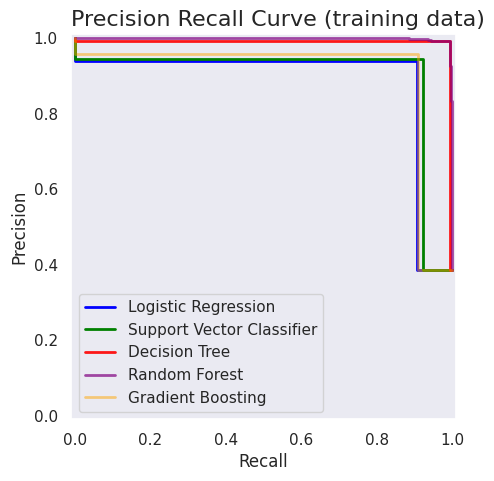

In [74]:
fig, ax = plt.subplots(figsize=(8,5))
lr_prdisplay.plot(ax=ax, label='Logistic Regression', color='blue', linewidth=2)
svc_prdisplay.plot(ax=ax, label='Support Vector Classifier', color='green', linewidth=2)
tree_prdisplay.plot(ax=ax, label='Decision Tree', color='red', linewidth=2, alpha=.9)
rf_prdisplay.plot(ax=ax, label='Random Forest', color='purple', linewidth=2, alpha=.7)
xg_prdisplay.plot(ax=ax, label='Gradient Boosting', color='orange', linewidth=2, alpha=.5)
plt.title('Precision Recall Curve (training data)', size=16, loc='left')
plt.show()

* Logistic Regression

In [75]:
lr_params = [
              {'C': uniform(loc=0, scale=4),
              'penalty': ['l1','l2'],
              'solver': ['liblinear','saga']}
              ]

lr_randomcv = RandomizedSearchCV(lr, lr_params, cv=skfold,
                                 scoring='f1',
                                 return_train_score = True,
                                 random_state = 10,
                                 n_iter=100)

lr_randomcv.fit(X_train_pp, y_train)

print("---------------- Logistic Regression ---------------")
print("Best Parameters: ", lr_randomcv.best_params_)
print("Best Score: ", lr_randomcv.best_score_)

---------------- Logistic Regression ---------------
Best Parameters:  {'C': np.float64(1.4933630402058768), 'penalty': 'l1', 'solver': 'liblinear'}
Best Score:  0.9213283314454961


* Random Forest

In [76]:
rf_params = [{
              'n_estimators': np.arange(50,500,50),
              'criterion': ['gini','entropy','logloss'],
              'max_depth': np.arange(2,14,2),
              'max_features': ['sqrt','log2',None, 0.5],
              }]

rf_randomcv = RandomizedSearchCV(rf, rf_params, cv=skfold,
                                 scoring='f1',
                                 return_train_score = True,
                                 random_state = 10,
                                 n_iter=100)

rf_randomcv.fit(X_train_pp, y_train)

print("----------------- Random Forest ----------------")
print("Best Parameters: ", rf_randomcv.best_params_)
print("Best Score: ", rf_randomcv.best_score_)

----------------- Random Forest ----------------
Best Parameters:  {'n_estimators': np.int64(400), 'max_features': None, 'max_depth': np.int64(10), 'criterion': 'gini'}
Best Score:  0.931218775008387


* Gradient Boosting

In [77]:
xg_params = [{
              'n_estimators': np.arange(50,500,50),
              'loss': ['exponential','log_loss'],
              'max_depth': np.arange(2,14,2),
              'criterion': ['friedman_mse', 'squared_error'],
              'learning_rate': uniform(loc=0,scale=.5),
              'max_features': ['sqrt', 'log2', None, 0.5]
              }]

xg_randomcv = RandomizedSearchCV(xg, xg_params, cv=skfold,
                                 scoring='f1',
                                 return_train_score = True,
                                 random_state = 10,
                                 n_iter=50)

xg_randomcv.fit(X_train_pp, y_train)

print("--------------- Gradient Boosting --------------")
print("Best Parameters: ", xg_randomcv.best_params_)
print("Best Score: ", xg_randomcv.best_score_)

--------------- Gradient Boosting --------------
Best Parameters:  {'criterion': 'squared_error', 'learning_rate': np.float64(0.09903143237981199), 'loss': 'exponential', 'max_depth': np.int64(4), 'max_features': 'sqrt', 'n_estimators': np.int64(450)}
Best Score:  0.9306190216509325


# Make Predictions

In [78]:
X_test = test.drop('Converted',axis=1)
y_test = test.loc[:,'Converted']

# Let's take a look of the first row
X_test.to_numpy()[:1]

array([['b4d86fa1-53d9-4a27-8d0c-f6603a562184', 634844, 'API', 'Google',
        'No', 'No', 2.0, 1551, 1.0, 'SMS Sent', 'India', nan, nan, nan,
        nan, 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', nan, nan,
        'No', 'No', nan, nan, '02.Medium', '02.Medium', 15.0, 15.0, 'No',
        'No', 'SMS Sent']], dtype=object)

In [79]:
# apply all the preprocessing steps to the test dataset
X_test_pp = pipe.transform(X_test)
X_test_pp.toarray()[:1]

array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0. 

# Random Forest with hyperparameter tuned

In [80]:
rf_rcv_pred = rf_randomcv.predict(X_test_pp)
print("Precision:", precision_score(y_test,rf_rcv_pred))
print("Recall:", recall_score(y_test,rf_rcv_pred))
print("F1 score:", f1_score(y_test,rf_rcv_pred))
print("ROC - AUC score:", roc_auc_score(y_test,rf_rcv_pred))

Precision: 0.9485294117647058
Recall: 0.9058988764044944
F1 score: 0.9267241379310345
ROC - AUC score: 0.9375445086247823


# Random Forest without hyperparameter tuned

In [81]:
rf_pred_test = rf.predict(X_test_pp)
print("Precision:", precision_score(y_test,rf_pred_test))
print("Recall:", recall_score(y_test,rf_pred_test))
print("F1 score:", f1_score(y_test,rf_pred_test))
print("ROC - AUC score:", roc_auc_score(y_test,rf_pred_test))

Precision: 0.9402332361516035
Recall: 0.9058988764044944
F1 score: 0.9227467811158798
ROC - AUC score: 0.9349036635543598


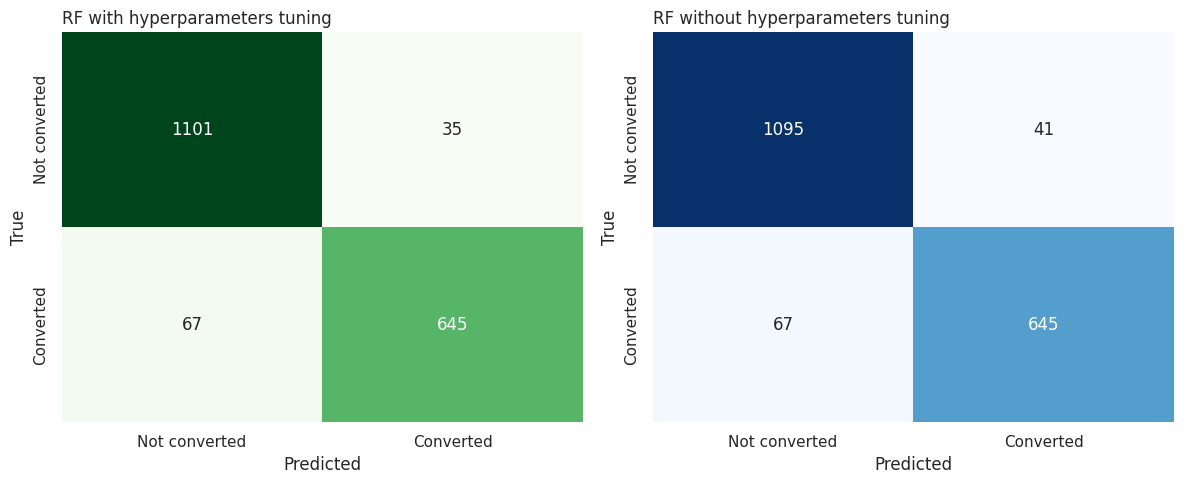

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest tunned
cm1 = confusion_matrix(y_test, rf_rcv_pred)
sns.heatmap(cm1, annot=True, fmt = 'd', cmap='Greens', ax = ax[0], cbar=False)
ax[0].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].set_title('RF with hyperparameters tuning', loc='left')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# Random Forest without tuning
cm2 = confusion_matrix(y_test, rf_pred_test)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].set_title('RF without hyperparameters tuning', loc='left')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()


# Submission

In [83]:
lead_scoring = rf_randomcv.predict_proba(X_test_pp)[:,1]
lead_prediction = rf_rcv_pred
results = np.round(np.c_[lead_prediction,lead_scoring],2)

# Let's take a look of the first 10 rows
results[:10]

array([[1.  , 0.97],
       [0.  , 0.2 ],
       [0.  , 0.02],
       [0.  , 0.01],
       [1.  , 1.  ],
       [1.  , 1.  ],
       [1.  , 1.  ],
       [1.  , 0.72],
       [0.  , 0.02],
       [0.  , 0.12]])

# Conclusion
In summary, our data science project focused on fine-tuning lead scoring for X Education. We aimed to exceed an 80% precision goal, which we not only met but exceeded. Throughout our journey, we identified key factors like phone interactions, referrals, and online engagement that strongly correlated with lead conversion, leading to actionable strategies.

One notable achievement was the development of an automated lead scoring algorithm that not only improved lead assessment precision but also streamlined operational efficiency. By targeting promising leads, X Education could reduce sales team costs significantly.

Our journey involved thorough data exploration, preprocessing, and model development, ensuring consistency and mitigating bias. We systematically evaluated models, with the tuned Random Forest model achieving an impressive F1 score of 0.9287 and a precision score of 0.9527 on the test dataset.

This data-driven journey provides X Education with actionable insights to enhance efficiency and revenue growth, positioning the company for a transformative phase.